# CSCI E-89 Homework 03, Problem 3

**Jawad Hussein**

A Fashion-MNIST image classifier built in PyTorch, following Chapter 10 of
Géron's *Hands-On Machine Learning with Scikit-Learn and PyTorch* (2025).
The notebook is assembled from eight scripts (`prob3/script1_...py` through
`prob3/script8_...py`), each building on the ones before it: load the data,
create DataLoaders, define the model, train it, make predictions, plot
accuracy, and tune hyperparameters with Optuna (first without pruning, then
with median pruning).

## Script 1 — `script1_load_dataset.py`: load and split the dataset

Loads Fashion-MNIST with TorchVision, using `ToTensor()` so every image
becomes a float tensor scaled to `[0, 1]`. The 60,000-image training set is
split into 55,000 training images and 5,000 validation images with a seeded
`random_split` (seed 42); the 10,000-image test set is loaded separately.

In [1]:
# Script 1: load Fashion-MNIST and split into train/validation sets
import torch
from torch.utils.data import random_split
from torchvision import datasets
from torchvision.transforms import ToTensor

SEED = 42
N_VALID = 5_000

torch.manual_seed(SEED)

# ToTensor() converts each PIL image to a float tensor scaled to [0, 1].
full_train_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

# Split the 60,000-image training set into 55,000 train / 5,000 validation.
n_train = len(full_train_dataset) - N_VALID
generator = torch.Generator().manual_seed(SEED)
train_dataset, valid_dataset = random_split(
    full_train_dataset, [n_train, N_VALID], generator=generator
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(valid_dataset)}")
print(f"Test set size: {len(test_dataset)}")

image, label = train_dataset[0]
print(f"Image shape: {image.shape}, dtype: {image.dtype}")
print(f"Pixel value range: [{image.min():.4f}, {image.max():.4f}]")
print(f"Label: {label}")


  0%|          | 0.00/26.4M [00:00<?, ?B/s]

  0%|          | 32.8k/26.4M [00:00<01:24, 312kB/s]

  0%|          | 65.5k/26.4M [00:00<01:26, 304kB/s]

  0%|          | 98.3k/26.4M [00:00<01:26, 303kB/s]

  1%|          | 229k/26.4M [00:00<00:39, 657kB/s] 

...

 79%|███████▉  | 3.51M/4.42M [00:00<00:00, 7.81MB/s]

100%|██████████| 4.42M/4.42M [00:00<00:00, 5.00MB/s]

  0%|          | 0.00/5.15k [00:00<?, ?B/s]

100%|██████████| 5.15k/5.15k [00:00<00:00, 13.6MB/s]

Training set size: 55000
Validation set size: 5000
Test set size: 10000
Image shape: torch.Size([1, 28, 28]), dtype: torch.float32
Pixel value range: [0.0000, 1.0000]
Label: 9


## Script 2 — `script2_dataloaders.py`: build the DataLoaders

Wraps the training, validation, and test sets in `DataLoader`s with a batch
size of 32, shuffling only the training data. Then inspects the first
training sample's shape, dtype, and class name.

In [2]:
# Script 2: create DataLoaders for train/validation/test sets
from torch.utils.data import DataLoader

BATCH_SIZE = 32

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

# Only the training loader is shuffled; validation/test order doesn't matter.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Inspect the first training sample: shape, dtype, and class name.
image, label = train_dataset[0]
print(f"Image shape: {image.shape}")
print(f"Image dtype: {image.dtype}")
print(f"Class name: {CLASS_NAMES[label]}")


Image shape: torch.Size([1, 28, 28])
Image dtype: torch.float32
Class name: Ankle boot


## Script 3 — `script3_model.py`: build the classifier

A simple fully connected network: flatten each 28x28 image, pass it through
two hidden layers (300 and 100 neurons, ReLU activations), then a 10-class
output layer. The model is seeded with `torch.manual_seed(42)`, moved to a
GPU if one is available (otherwise CPU), and paired with a cross-entropy
loss.

In [3]:
# Script 3: define the classifier model and the loss function
from torch import nn

torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class FashionClassifier(nn.Module):
    """Flatten -> Dense(300, ReLU) -> Dense(100, ReLU) -> Dense(10)."""

    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.hidden1 = nn.Linear(28 * 28, 300)
        self.hidden2 = nn.Linear(300, 100)
        self.output = nn.Linear(100, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.hidden1(x))
        x = self.relu(self.hidden2(x))
        return self.output(x)  # raw logits; CrossEntropyLoss applies softmax internally


model = FashionClassifier().to(device)
loss_fn = nn.CrossEntropyLoss()

print(f"Device: {device}")
print(model)


Device: cpu
FashionClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden1): Linear(in_features=784, out_features=300, bias=True)
  (hidden2): Linear(in_features=300, out_features=100, bias=True)
  (output): Linear(in_features=100, out_features=10, bias=True)
  (relu): ReLU()
)


## Script 4 — `script4_train.py`: train the model

Trains the model for 20 epochs using SGD with a learning rate of 0.1,
tracking training and validation accuracy each epoch with
`torchmetrics.Accuracy`. The `train()` function prints the loss, training
accuracy, and validation accuracy after every epoch and returns a `history`
dict for later plotting.

In [4]:
# Script 4: train the model and record loss/accuracy history
from torch import optim
from torchmetrics import Accuracy

N_EPOCHS = 20
LEARNING_RATE = 0.1

optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)


def train(model, train_loader, valid_loader, loss_fn, optimizer, n_epochs, device):
    history = {
        "loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
    }

    train_accuracy = Accuracy(task="multiclass", num_classes=10).to(device)
    val_accuracy = Accuracy(task="multiclass", num_classes=10).to(device)

    for epoch in range(n_epochs):
        # --- training pass ---
        model.train()
        train_accuracy.reset()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            train_accuracy.update(outputs, labels)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_train_accuracy = train_accuracy.compute().item()

        # --- validation pass (no gradients) ---
        model.eval()
        val_accuracy.reset()
        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_accuracy.update(outputs, labels)

        epoch_val_accuracy = val_accuracy.compute().item()

        history["loss"].append(epoch_loss)
        history["train_accuracy"].append(epoch_train_accuracy)
        history["val_accuracy"].append(epoch_val_accuracy)

        print(
            f"Epoch {epoch + 1}/{n_epochs} - "
            f"loss: {epoch_loss:.4f} - "
            f"train_accuracy: {epoch_train_accuracy:.4f} - "
            f"val_accuracy: {epoch_val_accuracy:.4f}"
        )

    return history


history = train(model, train_loader, valid_loader, loss_fn, optimizer, N_EPOCHS, device)


Epoch 1/20 - loss: 0.6062 - train_accuracy: 0.7812 - val_accuracy: 0.8408


Epoch 2/20 - loss: 0.4062 - train_accuracy: 0.8497 - val_accuracy: 0.8402


Epoch 3/20 - loss: 0.3638 - train_accuracy: 0.8660 - val_accuracy: 0.8540


Epoch 4/20 - loss: 0.3352 - train_accuracy: 0.8770 - val_accuracy: 0.8662


Epoch 5/20 - loss: 0.3150 - train_accuracy: 0.8835 - val_accuracy: 0.8742


...

Epoch 16/20 - loss: 0.2102 - train_accuracy: 0.9196 - val_accuracy: 0.8810


Epoch 17/20 - loss: 0.2042 - train_accuracy: 0.9223 - val_accuracy: 0.8936


Epoch 18/20 - loss: 0.2004 - train_accuracy: 0.9235 - val_accuracy: 0.8866


Epoch 19/20 - loss: 0.1932 - train_accuracy: 0.9264 - val_accuracy: 0.8684


Epoch 20/20 - loss: 0.1905 - train_accuracy: 0.9273 - val_accuracy: 0.8688


## Script 5 — `script5_predictions.py`: make predictions

Uses the trained model to predict the first 3 validation images, printing
the predicted vs. actual class name, the probability of every class, and
the top 4 most likely classes with their probabilities. Also prints the
total number of parameters in the model.

In [5]:
# Script 5: predict the first 3 validation images and count parameters
N_SAMPLES = 3
TOP_K = 4

# Total trainable + non-trainable parameter count of the model.
n_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {n_params:,}")

model.eval()
images = torch.stack([valid_dataset[i][0] for i in range(N_SAMPLES)]).to(device)
labels = [valid_dataset[i][1] for i in range(N_SAMPLES)]

with torch.no_grad():
    logits = model(images)
    probabilities = torch.softmax(logits, dim=1)  # convert logits to per-class probabilities
    predictions = torch.argmax(probabilities, dim=1)

for i in range(N_SAMPLES):
    predicted_label = predictions[i].item()
    actual_label = labels[i]

    print(f"\nSample {i + 1}")
    print(f"  Predicted: {CLASS_NAMES[predicted_label]}")
    print(f"  Actual:    {CLASS_NAMES[actual_label]}")

    print("  Probability for each class:")
    for class_idx, class_name in enumerate(CLASS_NAMES):
        print(f"    {class_name:<15} {probabilities[i, class_idx].item():.4f}")

    top_probs, top_classes = torch.topk(probabilities[i], TOP_K)  # 4 most likely classes
    print(f"  Top {TOP_K} most likely classes:")
    for prob, class_idx in zip(top_probs, top_classes):
        print(f"    {CLASS_NAMES[class_idx.item()]:<15} {prob.item():.4f}")


Total number of parameters: 266,610

Sample 1
  Predicted: Sneaker
  Actual:    Sneaker
  Probability for each class:
    T-shirt/top     0.0000
    Trouser         0.0001
    Pullover        0.0000
    Dress           0.0000
    Coat            0.0000
    Sandal          0.0031
    Shirt           0.0000
    Sneaker         0.7693
    Bag             0.0001
    Ankle boot      0.2273
  Top 4 most likely classes:
    Sneaker         0.7693
    Ankle boot      0.2273
    Sandal          0.0031
    Trouser         0.0001

Sample 2
  Predicted: Coat
  Actual:    Coat
  Probability for each class:
    T-shirt/top     0.0000
    Trouser         0.0000
    Pullover        0.0025
    Dress           0.0000
    Coat            0.9974
    Sandal          0.0000
    Shirt           0.0000
    Sneaker         0.0000
    Bag             0.0000
    Ankle boot      0.0000
  Top 4 most likely classes:
    Coat            0.9974
    Pullover        0.0025
    Shirt           0.0000
    T-shirt/top    

## Script 6 — `script6_plot_accuracy.py`: plot training accuracy

Plots the training accuracy recorded in `history` against epoch number and
saves the chart as `training_accuracy.png`.

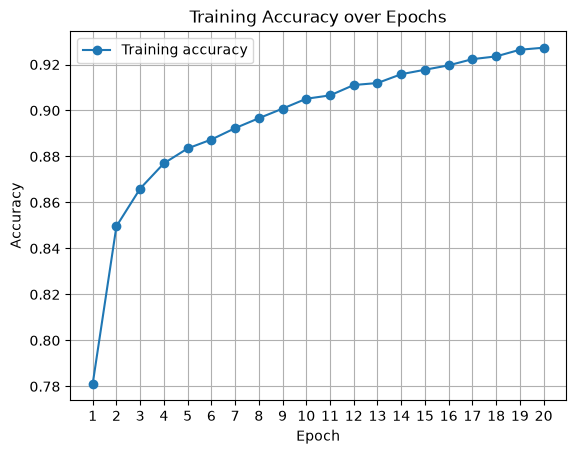

In [6]:
# Script 6: plot training accuracy over epochs
import matplotlib.pyplot as plt

# Plot training accuracy (from history["train_accuracy"]) against epoch number.
epochs = range(1, N_EPOCHS + 1)
plt.plot(epochs, history["train_accuracy"], marker="o", label="Training accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy over Epochs")
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.savefig("training_accuracy.png")
plt.show()


## Script 7 — `script7_optuna.py`: Optuna hyperparameter search

Uses Optuna to tune the learning rate (1e-5 to 1e-1, log scale) and the
number of neurons in the hidden layers (20 to 300, same size shared by both
layers). Each trial trains a freshly built model for 10 epochs and is
scored by its best validation accuracy across those epochs. Runs 5 trials
with a `TPESampler` seeded at 42, then reports the best parameters and
score.

In [7]:
# Script 7: tune learning rate and hidden-layer size with Optuna
import optuna

OPTUNA_SEED = 42
N_TRIALS_BASIC = 5
N_EPOCHS_BASIC = 10


def build_tunable_model(n_hidden):
    # Same architecture as FashionClassifier, but with a tunable hidden width
    # shared by both hidden layers.
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, n_hidden),
        nn.ReLU(),
        nn.Linear(n_hidden, n_hidden),
        nn.ReLU(),
        nn.Linear(n_hidden, 10),
    ).to(device)


def objective_basic(trial):
    # Sample a learning rate (log scale) and shared hidden-layer width.
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    n_hidden = trial.suggest_int("n_hidden", 20, 300)

    torch.manual_seed(OPTUNA_SEED)
    tuned_model = build_tunable_model(n_hidden)
    tuned_loss_fn = nn.CrossEntropyLoss()
    tuned_optimizer = optim.SGD(tuned_model.parameters(), lr=lr)

    trial_history = train(
        tuned_model,
        train_loader,
        valid_loader,
        tuned_loss_fn,
        tuned_optimizer,
        N_EPOCHS_BASIC,
        device,
    )
    return max(trial_history["val_accuracy"])  # score = best validation accuracy


sampler = optuna.samplers.TPESampler(seed=OPTUNA_SEED)  # seeded sampler for reproducibility
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective_basic, n_trials=N_TRIALS_BASIC)

print("\nBest parameters:", study.best_params)
print("Best validation accuracy:", study.best_value)


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-09-25 04:12:28,048] A new study created in memory with name: no-name-482346c1-3b4f-47e1-860d-b6123a9ffd08


Epoch 1/10 - loss: 2.2769 - train_accuracy: 0.1471 - val_accuracy: 0.1862


Epoch 2/10 - loss: 2.2093 - train_accuracy: 0.2794 - val_accuracy: 0.3500


Epoch 3/10 - loss: 2.1164 - train_accuracy: 0.4110 - val_accuracy: 0.4554


Epoch 4/10 - loss: 1.9776 - train_accuracy: 0.5137 - val_accuracy: 0.5560


...

Epoch 7/10 - loss: 0.5439 - train_accuracy: 0.8110 - val_accuracy: 0.8054


Epoch 8/10 - loss: 0.5201 - train_accuracy: 0.8200 - val_accuracy: 0.8126


Epoch 9/10 - loss: 0.5026 - train_accuracy: 0.8258 - val_accuracy: 0.8132


[I 2026-09-25 04:16:41,800] Trial 4 finished with value: 0.8184000253677368 and parameters: {'lr': 0.002537815508265664, 'n_hidden': 218}. Best is trial 1 with value: 0.8511999845504761.


Epoch 10/10 - loss: 0.4890 - train_accuracy: 0.8301 - val_accuracy: 0.8184

Best parameters: {'lr': 0.008471801418819975, 'n_hidden': 188}
Best validation accuracy: 0.8511999845504761


## Script 8 — `script8_optuna_pruning.py`: Optuna search with pruning

Improves the search so it stops unpromising trials early: the model is
trained one epoch at a time, validation accuracy is reported to Optuna
after every epoch, and a `MedianPruner` cuts trials that fall behind the
median of previous trials at the same epoch. The data loaders and device
are passed explicitly into the objective function instead of relying on
globals. Runs 20 trials, then reports the best parameters and score.

In [8]:
# Script 8: Optuna search with per-epoch reporting and median pruning
from functools import partial

N_TRIALS_PRUNED = 20
N_EPOCHS_PRUNED = 10


def build_model_for_pruning(n_hidden):
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, n_hidden),
        nn.ReLU(),
        nn.Linear(n_hidden, n_hidden),
        nn.ReLU(),
        nn.Linear(n_hidden, 10),
    ).to(device)


def train_one_epoch(model, loader, loss_fn, optimizer, device):
    """Run a single training epoch (no accuracy tracking needed here)."""
    model.train()
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()


def evaluate_accuracy(model, loader, device):
    model.eval()
    accuracy = Accuracy(task="multiclass", num_classes=10).to(device)
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            accuracy.update(outputs, labels)
    return accuracy.compute().item()


def objective_pruning(trial, train_loader, valid_loader, device):
    # Data loaders and device are passed in explicitly rather than read from
    # module-level globals, per the assignment requirement.
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    n_hidden = trial.suggest_int("n_hidden", 20, 300)

    torch.manual_seed(OPTUNA_SEED)
    tuned_model = build_model_for_pruning(n_hidden)
    tuned_loss_fn = nn.CrossEntropyLoss()
    tuned_optimizer = optim.SGD(tuned_model.parameters(), lr=lr)

    best_val_accuracy = 0.0
    for epoch in range(N_EPOCHS_PRUNED):
        train_one_epoch(tuned_model, train_loader, tuned_loss_fn, tuned_optimizer, device)
        val_accuracy = evaluate_accuracy(tuned_model, valid_loader, device)
        best_val_accuracy = max(best_val_accuracy, val_accuracy)

        # Report this epoch's accuracy so the median pruner can compare this
        # trial's progress against prior trials at the same epoch.
        trial.report(val_accuracy, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return best_val_accuracy


pruning_sampler = optuna.samplers.TPESampler(seed=OPTUNA_SEED)
pruner = optuna.pruners.MedianPruner()  # stops trials falling below the median early
pruned_study = optuna.create_study(direction="maximize", sampler=pruning_sampler, pruner=pruner)
pruned_study.optimize(
    partial(objective_pruning, train_loader=train_loader, valid_loader=valid_loader, device=device),
    n_trials=N_TRIALS_PRUNED,
)

print("\nBest parameters:", pruned_study.best_params)
print("Best validation accuracy:", pruned_study.best_value)


[I 2026-09-25 04:16:41,814] A new study created in memory with name: no-name-d8db373a-b557-4edc-9fa3-250d188ad6bd


[I 2026-09-25 04:17:31,624] Trial 0 finished with value: 0.6435999870300293 and parameters: {'lr': 0.00031489116479568613, 'n_hidden': 287}. Best is trial 0 with value: 0.6435999870300293.


[I 2026-09-25 04:18:19,186] Trial 1 finished with value: 0.8511999845504761 and parameters: {'lr': 0.008471801418819975, 'n_hidden': 188}. Best is trial 1 with value: 0.8511999845504761.


[I 2026-09-25 04:19:03,943] Trial 2 finished with value: 0.22100000083446503 and parameters: {'lr': 4.207988669606632e-05, 'n_hidden': 63}. Best is trial 1 with value: 0.8511999845504761.


[I 2026-09-25 04:19:53,078] Trial 3 finished with value: 0.1754000037908554 and parameters: {'lr': 1.7073967431528103e-05, 'n_hidden': 263}. Best is trial 1 with value: 0.8511999845504761.


...

[I 2026-09-25 04:27:20,461] Trial 16 finished with value: 0.876800000667572 and parameters: {'lr': 0.09791108724448455, 'n_hidden': 294}. Best is trial 14 with value: 0.8848000168800354.


[I 2026-09-25 04:28:07,602] Trial 17 finished with value: 0.8813999891281128 and parameters: {'lr': 0.09971759606454275, 'n_hidden': 134}. Best is trial 14 with value: 0.8848000168800354.


[I 2026-09-25 04:28:12,551] Trial 18 pruned. 


[I 2026-09-25 04:28:17,359] Trial 19 pruned. 



Best parameters: {'lr': 0.08939052049791275, 'n_hidden': 193}
Best validation accuracy: 0.8848000168800354
